In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from pathlib import Path
from tensorflow.keras.models import load_model


In [2]:
path=Path("D:/Plant Disease Project/dataset/plantvillage dataset/color")
print(path.exists())

True


In [6]:
for folder in path.iterdir():
    if folder.is_dir():
        print(folder.name," : ",len(list(folder.glob("*"))))

Apple___Apple_scab  :  630
Apple___Black_rot  :  621
Apple___Cedar_apple_rust  :  275
Apple___healthy  :  1645
Blueberry___healthy  :  1502
Cherry_(including_sour)___healthy  :  854
Cherry_(including_sour)___Powdery_mildew  :  1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  :  513
Corn_(maize)___Common_rust_  :  1192
Corn_(maize)___healthy  :  1162
Corn_(maize)___Northern_Leaf_Blight  :  985
Grape___Black_rot  :  1180
Grape___Esca_(Black_Measles)  :  1383
Grape___healthy  :  423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)  :  1076
Orange___Haunglongbing_(Citrus_greening)  :  5507
Peach___Bacterial_spot  :  2297
Peach___healthy  :  360
Pepper,_bell___Bacterial_spot  :  997
Pepper,_bell___healthy  :  1478
Potato___Early_blight  :  1000
Potato___healthy  :  152
Potato___Late_blight  :  1000
Raspberry___healthy  :  371
Soybean___healthy  :  5090
Squash___Powdery_mildew  :  1835
Strawberry___healthy  :  456
Strawberry___Leaf_scorch  :  1109
Tomato___Bacterial_spot  :  2127
Tomato___

In [ ]:
print(len(list(path.iterdir())))

38


In [30]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    seed=123,
    subset="training",
    image_size=(224,224),
    batch_size=16,
    label_mode="int"
)
validation_ds=tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    seed=123,
    subset="validation",
    image_size=(224,224),
    batch_size=16,
    label_mode="int"
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [5]:
class_names=train_ds.class_names
print(class_names)
print(len(class_names))
print(len(validation_ds.class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

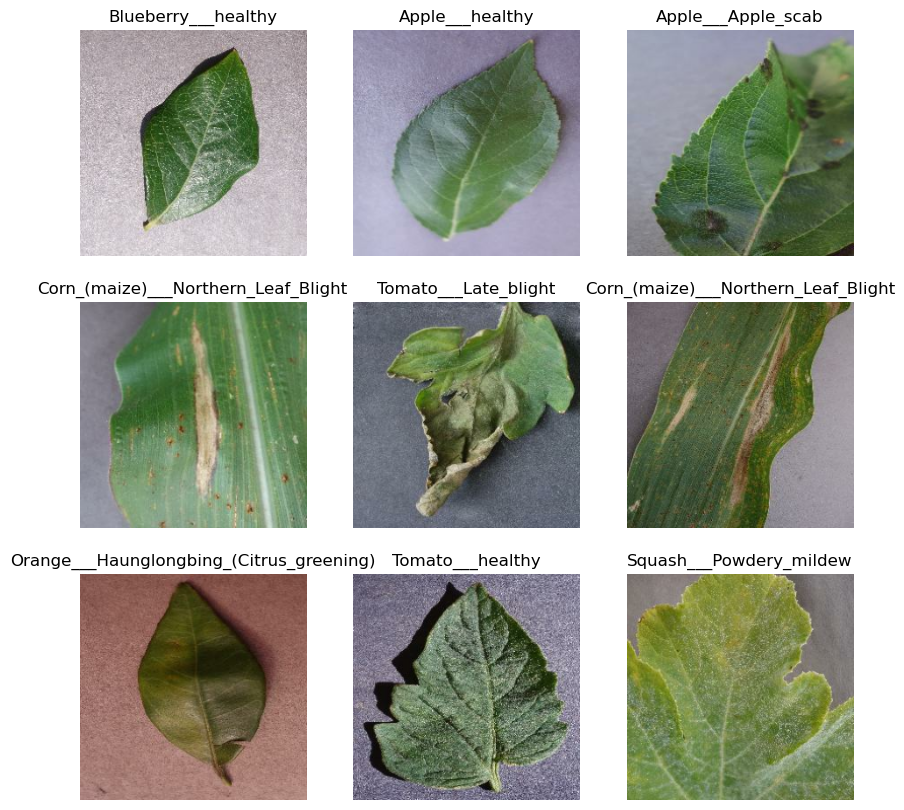

In [10]:
for images,labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [6]:
train_ds=train_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)
validation_ds=validation_ds.prefetch(tf.data.AUTOTUNE)

In [31]:
data_augmentation=tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    RandomContrast(0.1)
])

In [32]:
base_model=ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
    

In [33]:
base_model.trainable = False

In [34]:
model = Sequential([
    data_augmentation,

    Lambda(preprocess_input),

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),

    Dropout(0.3),

    Dense(38, activation="softmax")
])

In [35]:
model.build((None,224,224,3))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,122,022 (92.02 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [25]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3881s 1s/step - accuracy: 0.8744 - loss: 0.4141 - val_accuracy: 0.9456 - val_loss: 0.1666
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3733s 1s/step - accuracy: 0.9308 - loss: 0.2096 - val_accuracy: 0.9308 - val_loss: 0.2163
Epoch 3/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3729s 1s/step - accuracy: 0.9422 - loss: 0.1778 - val_accuracy: 0.9472 - val_loss: 0.1550
Epoch 4/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3739s 1s/step - accuracy: 0.9466 - loss: 0.1579 - val_accuracy: 0.9521 - val_loss: 0.1499
Epoch 5/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3773s 1s/step - accuracy: 0.9491 - loss: 0.1600 - val_accuracy: 0.9646 - val_loss: 0.1195
Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3748s 1s/step - accuracy: 0.9549 - loss: 0.1420 - val_accuracy: 0.9330 - val_loss: 0.2397
Epoch 7/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3738s 1s/step - accuracy: 0.9562 - loss: 0.1401 - val_accuracy: 0.9456 - val_loss: 0.2087
Epoch 8/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 3736s 1s/step - accuracy: 0.9571 -

In [26]:
import json

class_names = train_ds.class_names

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [67]:
model = load_model(
    r"D:\Plant Disease Project\models\best_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print("model loaded successfully")

model loaded successfully


In [16]:
loss, acc = model.evaluate(validation_ds)

print(loss)
print(acc)

679/679 ━━━━━━━━━━━━━━━━━━━━ 1138s 2s/step - accuracy: 0.9704 - loss: 0.0981
0.09813820570707321
0.9704447388648987


In [17]:
y_true = []
y_pred = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Accuracy:", np.mean(y_true == y_pred))
print(y_true.shape)
print(y_pred.shape)

Accuracy: 0.9704447104318202
(10861,)
(10861,)


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm.shape)
print(cm.sum())
print(cm.max())

(38, 38)
10861
1136


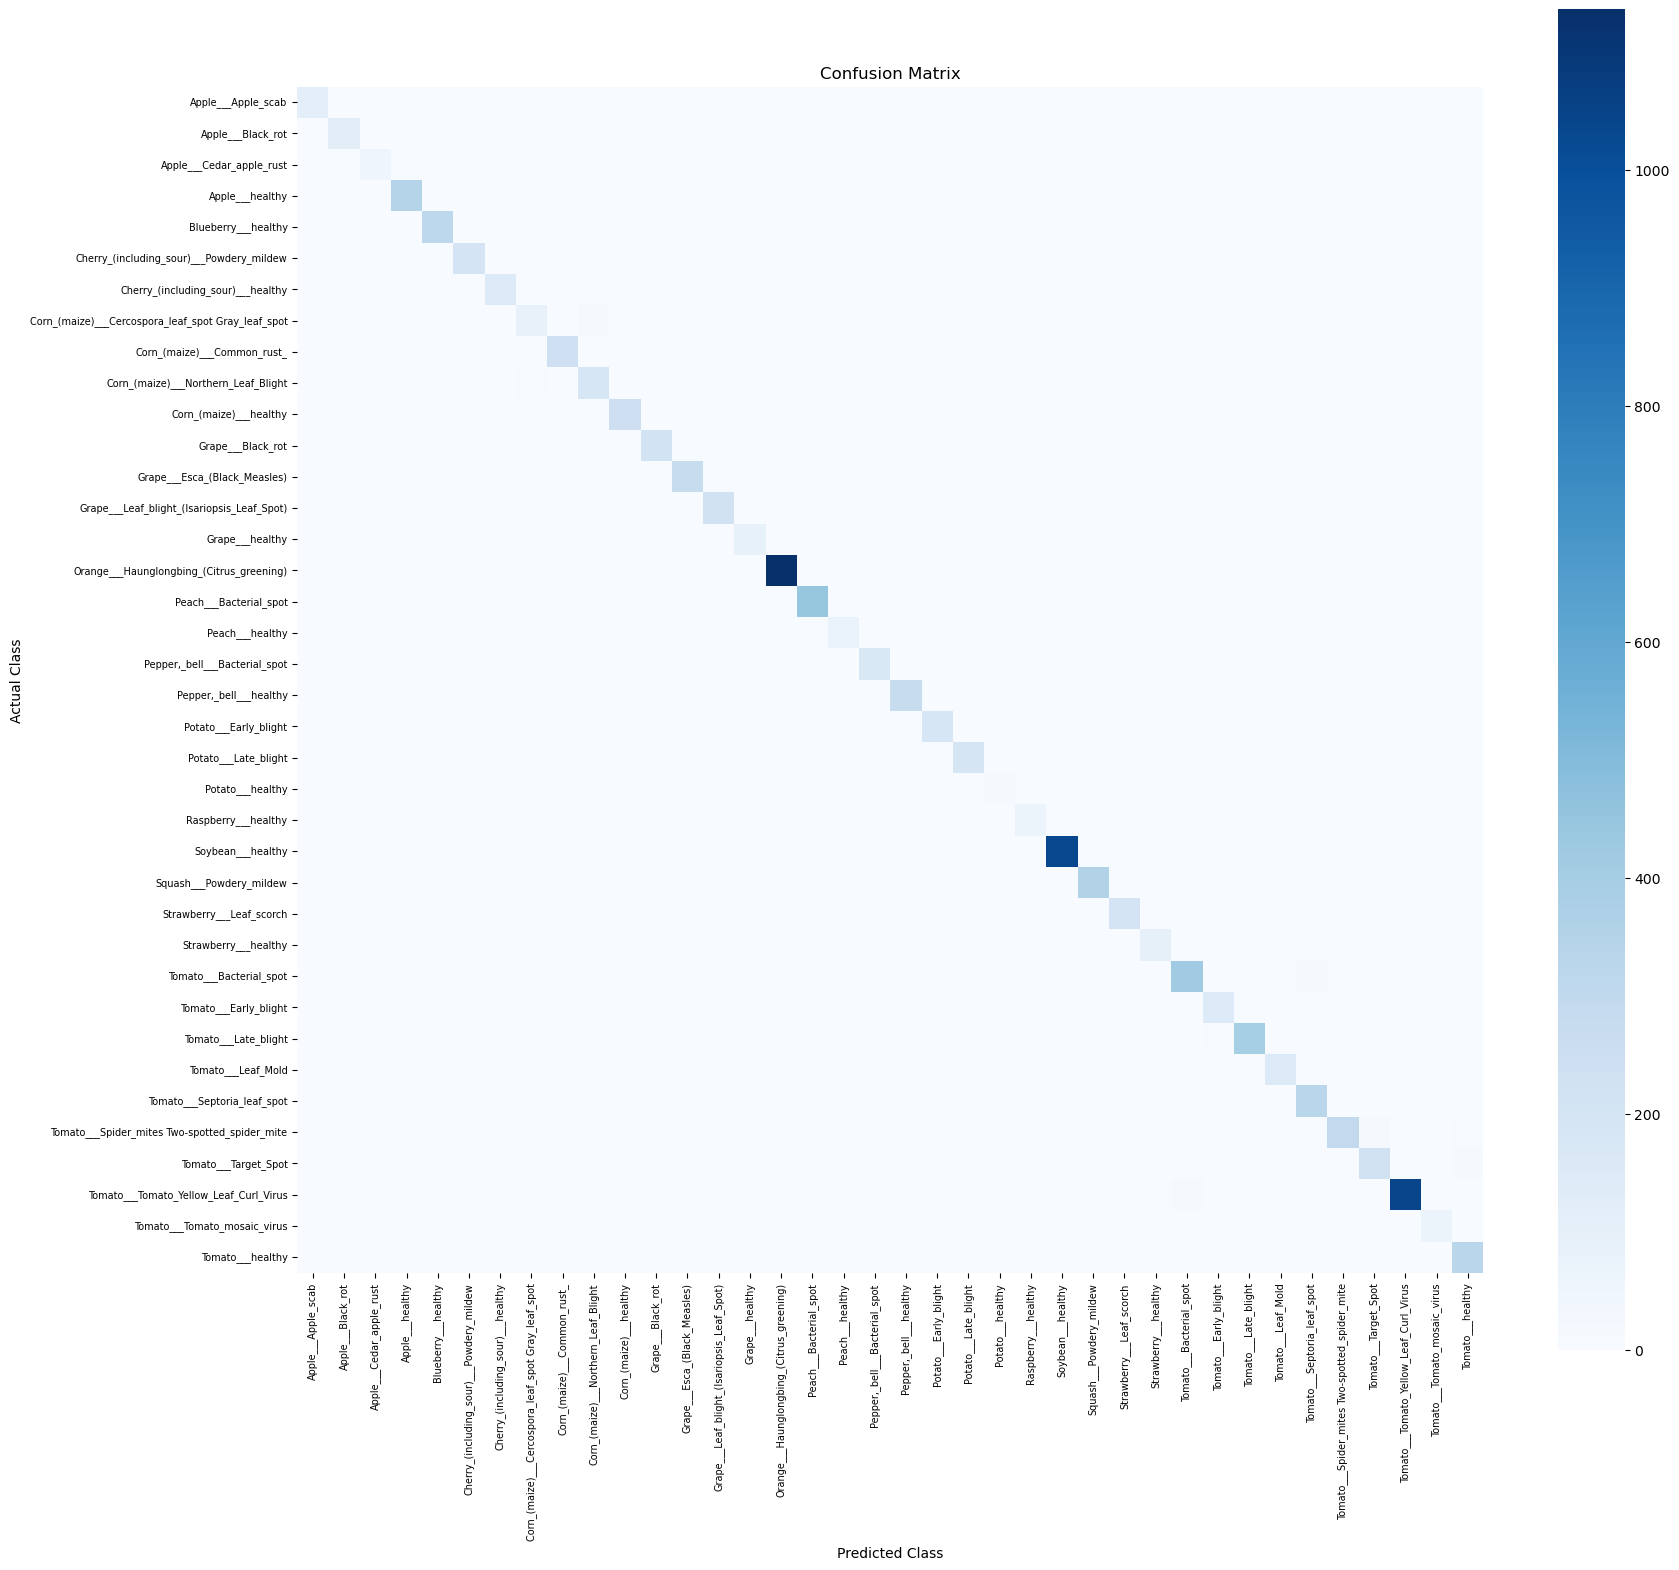

In [23]:
import seaborn as sn
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 16))

sn.heatmap(
    cm,
    cmap="Blues",
    square=True,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig(
    r"D:\Plant Disease Project\predictions\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.99      0.96       120
                                 Apple___Black_rot       0.98      0.99      0.99       124
                          Apple___Cedar_apple_rust       1.00      0.95      0.97        56
                                   Apple___healthy       0.96      0.99      0.97       348
                               Blueberry___healthy       0.99      1.00      1.00       318
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       208
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.80      0.84       109
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.94      0.

In [25]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   - -------------------------------------- 1.3/44.0 MB 7.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.4/44.0 MB 6.5 MB/s eta 0:00:07
   --- ------------------------------------ 3.9/44.0 MB 6.3 MB/s eta 0:00:07
   ---- ----------------------------------- 5.2/44.0 MB 6.0 MB/s eta 0:00:07
   ------ --------------------------------- 7.1/44.0 MB 6.5 MB/s eta 0:00:06
   ------- -------------------------------- 8.4/44.0 MB 6.7 MB/s eta 0:00:06
   -------- ------------------------------- 9.2/44.0 MB 6.1 MB/s eta 0:00:06
   --------- ------------------------------ 10.7/44.0 MB 6.2 MB/s eta 0:00:06
   ----------- ---------------------------- 12.6/44.0 MB 6.5 MB/s eta 0:00:05
   ------------ --------------------------- 13.6/44.0 MB 6.4 MB/s eta 0:00:05
   ------------- -------------------------- 14.7/44.0 MB 6.3 MB/s eta 0:00:05
   -------------- ------------------------- 16.3/44.0 MB 6.4 MB/s eta 0:00:05
 

In [68]:
import matplotlib.cm as mpl_cm
import cv2
from tensorflow.keras.preprocessing import image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

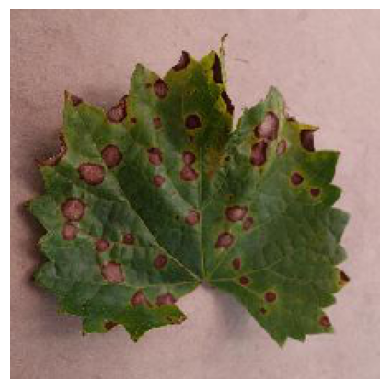

In [81]:
img_path = r"D:\Plant Disease Project\pv_test_images\grape_black_rot.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")

In [82]:
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)

print(class_names[predicted_index])
print(prediction[0][predicted_index])

Grape___Black_rot
0.99999785


In [83]:
base_model = model.get_layer("resnet50")

print(base_model.name)

resnet50


In [84]:
last_conv_layer = base_model.get_layer("conv5_block3_out")

print(last_conv_layer.name)
print(last_conv_layer.output.shape)

conv5_block3_out
(None, 7, 7, 2048)


In [85]:
with tf.GradientTape() as tape:

    conv_output = base_model(img_array, training=False)

    tape.watch(conv_output)

    x = model.get_layer("global_average_pooling2d_1")(conv_output)
    x = model.get_layer("dense_2")(x)
    x = model.get_layer("dropout_1")(x)

    predictions = model.get_layer("dense_3")(x)

    predicted_class = tf.argmax(predictions[0])

    class_score = predictions[:, predicted_class]

In [86]:
print(conv_output.shape)
print(predictions.shape)
print(predicted_class.numpy())

(1, 7, 7, 2048)
(1, 38)
12


In [87]:
grads = tape.gradient(class_score, conv_output)

print(grads.shape)

(1, 7, 7, 2048)


In [88]:
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

print(pooled_grads.shape)

(2048,)


In [89]:
conv_output = conv_output[0]          # (7,7,2048)

heatmap = tf.reduce_sum(
    conv_output * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(heatmap, 0)

heatmap /= tf.reduce_max(heatmap)

print(heatmap.shape)

(7, 7)


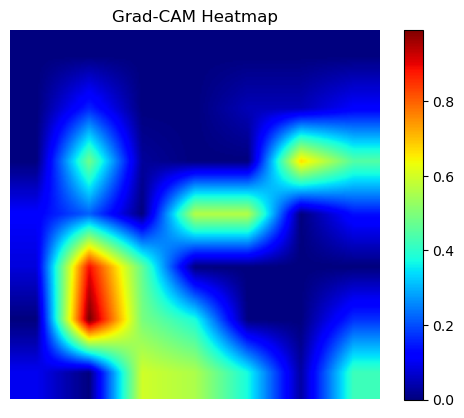

In [90]:
heatmap = heatmap.numpy()

heatmap = cv2.resize(
    heatmap,
    (224, 224)
)

plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

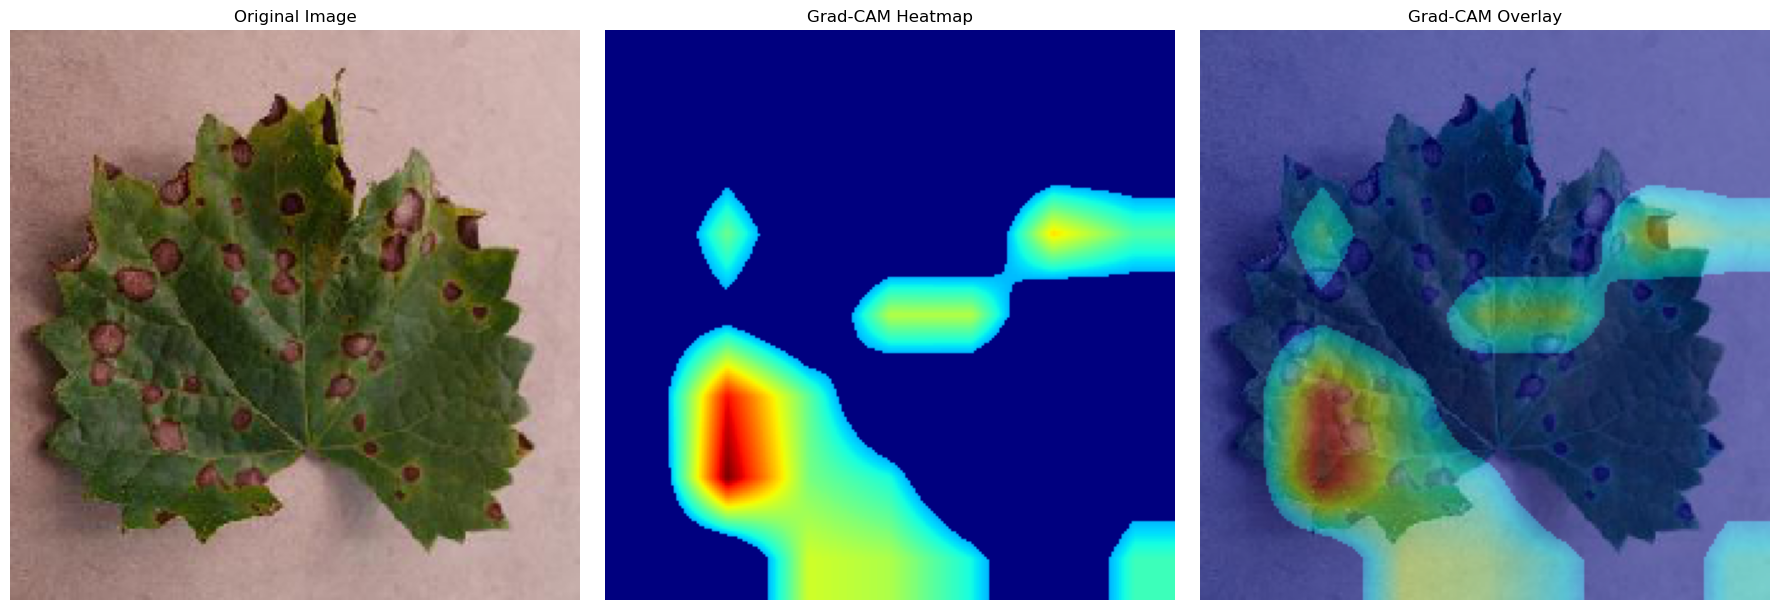

True

In [ ]:


# Remove weak activations
heatmap[heatmap < 0.3] = 0

# Resize to original image size
heatmap = cv2.resize(heatmap, (224, 224))

# Normalize to 0-255
heatmap = np.uint8(255 * heatmap)

# Apply JET colormap
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Original image
original = img_array[0].astype(np.uint8)

# Overlay
superimposed_img = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display all three images
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# Save overlay
cv2.imwrite(
    r"D:\Plant Disease Project\predictions\gradcam_overlay.png",
    superimposed_img
)